In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
from time import time

warnings.filterwarnings('ignore', category=UserWarning)

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)



In [2]:
# carregando os conjuntos pré-processados no notebook 7.2
pasta_dados = '../dados/dados_processados/zero_day/'

df_original = pd.read_csv(os.path.join(pasta_dados, 'avaliacao_normalizado.csv'))
df_pca      = pd.read_csv(os.path.join(pasta_dados, 'avaliacao_pca.csv'))
df_lda      = pd.read_csv(os.path.join(pasta_dados, 'avaliacao_lda.csv'))

print("Conjuntos de avaliação carregados:\n")
print("=" * 55)
print(f"  Original (normalizado): {df_original.shape}")
print(f"  PCA:                    {df_pca.shape}")
print(f"  LDA:                    {df_lda.shape}")
print("=" * 55)

# separando X e y de cada conjunto
y_avaliacao = df_original['Label'].copy()

X_original = df_original.drop(columns=['Label'])
X_pca      = df_pca.drop(columns=['Label'])
X_lda      = df_lda.drop(columns=['Label'])

print(f"\nDistribuição das classes (mesma nos 3 conjuntos):")
for classe, qtd in y_avaliacao.value_counts().items():
    pct = (qtd / len(y_avaliacao)) * 100
    print(f"  {classe:30s} → {qtd:>6,} ({pct:.2f}%)")


Conjuntos de avaliação carregados:

  Original (normalizado): (147, 79)
  PCA:                    (147, 16)
  LDA:                    (147, 4)

Distribuição das classes (mesma nos 3 conjuntos):
  BENIGN                         →    100 (68.03%)
  Infiltration                   →     36 (24.49%)
  Heartbleed                     →     11 (7.48%)


In [3]:
pasta_modelos = '../modelos/'

# dicionário organizando os modelos por algoritmo e versão de dados
modelos = {
    'Random Forest': {
        'original': joblib.load(os.path.join(pasta_modelos, 'modelo_rf_original.pkl')),
        'pca':      joblib.load(os.path.join(pasta_modelos, 'modelo_rf_pca.pkl')),
        'lda':      joblib.load(os.path.join(pasta_modelos, 'modelo_rf_lda.pkl')),
    },
    'XGBoost': {
        'original': joblib.load(os.path.join(pasta_modelos, 'modelo_xgb_original.pkl')),
        'pca':      joblib.load(os.path.join(pasta_modelos, 'modelo_xgb_pca.pkl')),
        'lda':      joblib.load(os.path.join(pasta_modelos, 'modelo_xgb_lda.pkl')),
    },
    'Isolation Forest': {
        'original': joblib.load(os.path.join(pasta_modelos, 'modelo_if_original.pkl')),
        'pca':      joblib.load(os.path.join(pasta_modelos, 'modelo_if_pca.pkl')),
        'lda':      joblib.load(os.path.join(pasta_modelos, 'modelo_if_lda.pkl')),
    },
    'Mean Shift': {
        'original': joblib.load(os.path.join(pasta_modelos, 'modelo_ms_original.pkl')),
        'pca':      joblib.load(os.path.join(pasta_modelos, 'modelo_ms_pca.pkl')),
        'lda':      joblib.load(os.path.join(pasta_modelos, 'modelo_ms_lda.pkl')),
    },
}

# carregando o codificador de rótulos do treino (para decodificar predições dos supervisionados)
codificador = joblib.load(os.path.join(pasta_modelos, 'codificador_rotulos_amostrado.pkl'))

print("Modelos carregados com sucesso:\n")
print("=" * 55)
for algoritmo, versoes in modelos.items():
    print(f"\n  {algoritmo}:")
    for versao, modelo in versoes.items():
        print(f"     • {versao:8s} → {type(modelo).__name__}")
print("\n" + "=" * 55)

print(f"\nCodificador de rótulos:")
print(f"  Classes vistas no treino: {list(codificador.classes_)}")


Modelos carregados com sucesso:


  Random Forest:
     • original → RandomForestClassifier
     • pca      → RandomForestClassifier
     • lda      → RandomForestClassifier

  XGBoost:
     • original → XGBClassifier
     • pca      → XGBClassifier
     • lda      → XGBClassifier

  Isolation Forest:
     • original → IsolationForest
     • pca      → IsolationForest
     • lda      → IsolationForest

  Mean Shift:
     • original → MeanShift
     • pca      → MeanShift
     • lda      → MeanShift


Codificador de rótulos:
  Classes vistas no treino: ['BENIGN', 'DDoS', 'DoS Hulk', 'PortScan']


In [4]:
def predizer(modelo, X, nome_algoritmo):
    """
    Aplica o modelo nos dados e retorna predições padronizadas como strings.
    
    - Supervisionados (RF, XGB): retornam classe prevista (BENIGN, DDoS, etc.)
    - Não-supervisionados (IF, MS): retornam 'NORMAL' ou 'ANOMALIA'
    """
    inicio = time()
    
    if nome_algoritmo in ['Random Forest', 'XGBoost']:
        # modelos supervisionados → predizem rótulo de classe
        y_pred_num = modelo.predict(X)
        y_pred = codificador.inverse_transform(y_pred_num)
    
    elif nome_algoritmo == 'Isolation Forest':
        # Isolation Forest → +1 = normal, -1 = anomalia
        y_pred_raw = modelo.predict(X)
        y_pred = np.where(y_pred_raw == -1, 'ANOMALIA', 'NORMAL')
    
    elif nome_algoritmo == 'Mean Shift':
        # Mean Shift → cada ponto recebe um cluster_id; tratamos pontos fora dos clusters principais como anomalia
        # Estratégia: o(s) maior(es) cluster(s) do treino representam "normal"; qualquer outro = anomalia
        labels_cluster = modelo.predict(X)
        # cluster 0 é normalmente o mais denso (BENIGN no treino); demais = potencial anomalia
        y_pred = np.where(labels_cluster == 0, 'NORMAL', 'ANOMALIA')
    
    tempo = time() - inicio
    return y_pred, tempo


print("Função de predição definida ✅")
print("\nLógica aplicada:")
print("  • RF e XGB     → classe prevista (BENIGN, DDoS, PortScan, DoS Hulk)")
print("  • IF           → ANOMALIA (-1) ou NORMAL (+1)")
print("  • MS           → ANOMALIA (cluster diferente do principal) ou NORMAL")


Função de predição definida ✅

Lógica aplicada:
  • RF e XGB     → classe prevista (BENIGN, DDoS, PortScan, DoS Hulk)
  • IF           → ANOMALIA (-1) ou NORMAL (+1)
  • MS           → ANOMALIA (cluster diferente do principal) ou NORMAL


In [5]:
# mapeamento entre versão e conjunto de dados correspondente
conjuntos_X = {
    'original': X_original,
    'pca':      X_pca,
    'lda':      X_lda,
}

resultados = {}  

print("Aplicando os 12 modelos nos dados zero-day...\n")
print("=" * 65)

for algoritmo, versoes in modelos.items():
    print(f"\n▶ {algoritmo}")
    for versao, modelo in versoes.items():
        X = conjuntos_X[versao]
        y_pred, tempo = predizer(modelo, X, algoritmo)
        
        resultados[(algoritmo, versao)] = {
            'predicoes': y_pred,
            'tempo': tempo,
            'n_amostras': len(y_pred)
        }
        
        print(f"   • {versao:8s} → {len(y_pred):,} predições em {tempo:.3f}s")

print("\n" + "=" * 65)
print(f"Total de combinações processadas: {len(resultados)}")


Aplicando os 12 modelos nos dados zero-day...


▶ Random Forest
   • original → 147 predições em 0.119s
   • pca      → 147 predições em 0.048s
   • lda      → 147 predições em 0.047s

▶ XGBoost
   • original → 147 predições em 0.040s
   • pca      → 147 predições em 0.007s
   • lda      → 147 predições em 0.004s

▶ Isolation Forest
   • original → 147 predições em 0.015s
   • pca      → 147 predições em 0.012s
   • lda      → 147 predições em 0.013s

▶ Mean Shift
   • original → 147 predições em 0.004s
   • pca      → 147 predições em 0.002s
   • lda      → 147 predições em 0.002s

Total de combinações processadas: 12


In [6]:
# montando um resumo das predições de cada modelo
print("Distribuição das predições por modelo:\n")
print("=" * 75)

for (algoritmo, versao), info in resultados.items():
    y_pred = info['predicoes']
    valores, contagens = np.unique(y_pred, return_counts=True)
    
    print(f"\n▶ {algoritmo} ({versao})")
    for val, cnt in zip(valores, contagens):
        pct = (cnt / len(y_pred)) * 100
        print(f"     {val:15s} → {cnt:>6,} ({pct:5.2f}%)")

print("\n" + "=" * 75)


Distribuição das predições por modelo:


▶ Random Forest (original)
     BENIGN          →    147 (100.00%)

▶ Random Forest (pca)
     BENIGN          →    135 (91.84%)
     DoS Hulk        →     10 ( 6.80%)
     PortScan        →      2 ( 1.36%)

▶ Random Forest (lda)
     BENIGN          →    128 (87.07%)
     DDoS            →      1 ( 0.68%)
     DoS Hulk        →      6 ( 4.08%)
     PortScan        →     12 ( 8.16%)

▶ XGBoost (original)
     BENIGN          →    141 (95.92%)
     DoS Hulk        →      6 ( 4.08%)

▶ XGBoost (pca)
     BENIGN          →    132 (89.80%)
     DDoS            →      1 ( 0.68%)
     DoS Hulk        →     10 ( 6.80%)
     PortScan        →      4 ( 2.72%)

▶ XGBoost (lda)
     BENIGN          →    125 (85.03%)
     DDoS            →      3 ( 2.04%)
     DoS Hulk        →      7 ( 4.76%)
     PortScan        →     12 ( 8.16%)

▶ Isolation Forest (original)
     ANOMALIA        →     61 (41.50%)
     NORMAL          →     86 (58.50%)

▶ Isolation Fores

In [7]:
# construindo um DataFrame onde cada linha é um registro e cada coluna é (algoritmo + versao)
df_predicoes = pd.DataFrame({'Label_real': y_avaliacao.values})

for (algoritmo, versao), info in resultados.items():
    # abreviação para nome da coluna
    abrev = {
        'Random Forest':    'RF',
        'XGBoost':          'XGB',
        'Isolation Forest': 'IF',
        'Mean Shift':       'MS',
    }[algoritmo]
    
    nome_coluna = f'{abrev}_{versao}'
    df_predicoes[nome_coluna] = info['predicoes']

print(f"DataFrame consolidado: {df_predicoes.shape}")
print(f"\nPrimeiras 10 linhas:")
print(df_predicoes.head(10))
print(f"\nColunas: {list(df_predicoes.columns)}")


DataFrame consolidado: (147, 13)

Primeiras 10 linhas:
     Label_real RF_original  RF_pca    RF_lda XGB_original XGB_pca   XGB_lda  \
0  Infiltration      BENIGN  BENIGN    BENIGN       BENIGN  BENIGN    BENIGN   
1  Infiltration      BENIGN  BENIGN    BENIGN       BENIGN  BENIGN    BENIGN   
2  Infiltration      BENIGN  BENIGN  DoS Hulk       BENIGN  BENIGN  DoS Hulk   
3  Infiltration      BENIGN  BENIGN    BENIGN       BENIGN  BENIGN    BENIGN   
4  Infiltration      BENIGN  BENIGN  DoS Hulk       BENIGN  BENIGN  DoS Hulk   
5  Infiltration      BENIGN  BENIGN  DoS Hulk       BENIGN  BENIGN  DoS Hulk   
6  Infiltration      BENIGN  BENIGN  DoS Hulk       BENIGN  BENIGN  DoS Hulk   
7  Infiltration      BENIGN  BENIGN    BENIGN       BENIGN  BENIGN    BENIGN   
8  Infiltration      BENIGN  BENIGN  DoS Hulk       BENIGN  BENIGN  DoS Hulk   
9  Infiltration      BENIGN  BENIGN    BENIGN       BENIGN  BENIGN    BENIGN   

  IF_original    IF_pca    IF_lda MS_original    MS_pca    MS_ld

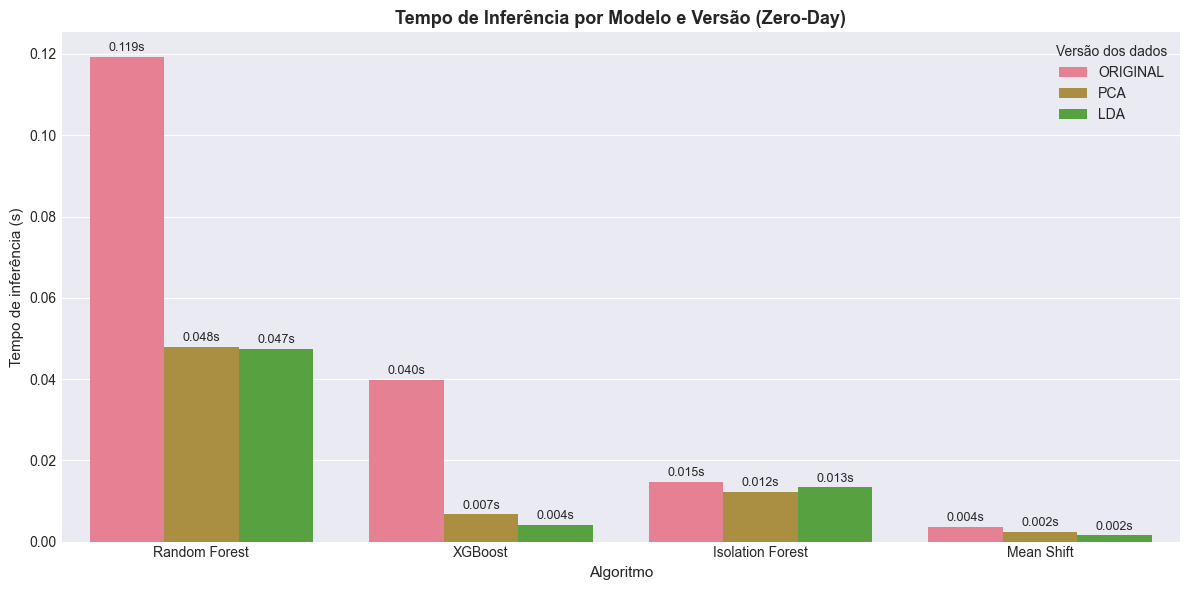

In [8]:
# montando dataframe de tempos para visualização
dados_tempo = []
for (algoritmo, versao), info in resultados.items():
    dados_tempo.append({
        'Algoritmo': algoritmo,
        'Versão':    versao.upper(),
        'Tempo (s)': info['tempo']
    })

df_tempos = pd.DataFrame(dados_tempo)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_tempos, x='Algoritmo', y='Tempo (s)', hue='Versão', ax=ax)
ax.set_title('Tempo de Inferência por Modelo e Versão (Zero-Day)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Algoritmo', fontsize=11)
ax.set_ylabel('Tempo de inferência (s)', fontsize=11)
ax.legend(title='Versão dos dados')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3fs', fontsize=9, padding=2)

plt.tight_layout()
plt.show()


In [9]:
pasta_saida = '../dados/dados_processados/zero_day/'
os.makedirs(pasta_saida, exist_ok=True)

caminho_saida = os.path.join(pasta_saida, 'predicoes_zero_day.csv')
df_predicoes.to_csv(caminho_saida, index=False)

# salvando também os tempos
caminho_tempos = os.path.join(pasta_saida, 'tempos_inferencia.csv')
df_tempos.to_csv(caminho_tempos, index=False)

print("Arquivos salvos com sucesso:\n")
print("=" * 65)
print(f"  [Predições]  {caminho_saida}")
print(f"               Shape: {df_predicoes.shape} | "
      f"Tamanho: {os.path.getsize(caminho_saida)/1024:.1f} KB\n")
print(f"  [Tempos]     {caminho_tempos}")
print(f"               Shape: {df_tempos.shape} | "
      f"Tamanho: {os.path.getsize(caminho_tempos)/1024:.1f} KB")
print("=" * 65)


Arquivos salvos com sucesso:

  [Predições]  ../dados/dados_processados/zero_day/predicoes_zero_day.csv
               Shape: (147, 13) | Tamanho: 14.6 KB

  [Tempos]     ../dados/dados_processados/zero_day/tempos_inferencia.csv
               Shape: (12, 3) | Tamanho: 0.5 KB


In [10]:
print("=" * 65)
print("        RESUMO DA APLICAÇÃO DOS MODELOS EM ZERO-DAY (7.3)")
print("=" * 65)

print(f"\n Registros avaliados:        {len(y_avaliacao):,}")
print(f" Modelos aplicados:          12 (4 algoritmos × 3 versões)")
print(f" Classes reais no conjunto:  {y_avaliacao.nunique()}")

print(f"\n Algoritmos:")
print(f"     • Supervisionados:      Random Forest, XGBoost")
print(f"     • Não-supervisionados:  Isolation Forest, Mean Shift")

print(f"\n Versões dos dados:")
print(f"     • Original (78 features normalizadas)")
print(f"     • PCA      ({X_pca.shape[1]} componentes)")
print(f"     • LDA      ({X_lda.shape[1]} componentes)")

tempo_total = sum(info['tempo'] for info in resultados.values())
print(f"\n Tempo total de inferência:  {tempo_total:.3f}s")
print(f" Tempo médio por modelo:     {tempo_total/12:.3f}s")

print(f"\n Saídas geradas:")
print(f"     • predicoes_zero_day.csv    → shape {df_predicoes.shape}")
print(f"     • tempos_inferencia.csv     → shape {df_tempos.shape}")




        RESUMO DA APLICAÇÃO DOS MODELOS EM ZERO-DAY (7.3)

 Registros avaliados:        147
 Modelos aplicados:          12 (4 algoritmos × 3 versões)
 Classes reais no conjunto:  3

 Algoritmos:
     • Supervisionados:      Random Forest, XGBoost
     • Não-supervisionados:  Isolation Forest, Mean Shift

 Versões dos dados:
     • Original (78 features normalizadas)
     • PCA      (15 componentes)
     • LDA      (3 componentes)

 Tempo total de inferência:  0.313s
 Tempo médio por modelo:     0.026s

 Saídas geradas:
     • predicoes_zero_day.csv    → shape (147, 13)
     • tempos_inferencia.csv     → shape (12, 3)
